# Taller 3.2 — Z-Buffer y Depth Testing

## Objetivo
Implementar el Z-buffer desde cero en Python, comparar el resultado con el algoritmo del pintor (painter's algorithm), visualizar el depth buffer y explorar Z-fighting y precisión near/far.

## 1. Instalación automática de dependencias

In [1]:
import subprocess
import sys

libraries = ['numpy', 'matplotlib', 'imageio', 'pillow']

for lib in libraries:
    try:
        __import__(lib if lib != 'pillow' else 'PIL')
        print(f'✓ {lib} ya está instalado')
    except ImportError:
        print(f'Installing {lib}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print(f'✓ {lib} instalado correctamente')

print('\n✅ Todas las dependencias están listas!')

✓ numpy ya está instalado
✓ matplotlib ya está instalado
✓ imageio ya está instalado
✓ pillow ya está instalado

✅ Todas las dependencias están listas!


## 2. Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import imageio
import os
import warnings
warnings.filterwarnings('ignore')

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


## 3. Utilidades de proyección y rasterización

### Proyección perspectiva (3D → 2D)

$$x_{screen} = \frac{f \cdot X}{Z}, \quad y_{screen} = \frac{f \cdot Y}{Z}$$

In [3]:
# Canvas dimensions
W, H = 512, 512
FOCAL = 400.0   # focal length (pixels)
CX, CY = W / 2, H / 2   # principal point

def project(v3d):
    """Project a 3-D point (X, Y, Z) → (px, py) pixel coords."""
    X, Y, Z = v3d
    if Z <= 0:
        return None
    px = FOCAL * X / Z + CX
    py = -FOCAL * Y / Z + CY   # flip Y so +Y is up
    return np.array([px, py])

def edge_function(a, b, c):
    """2-D cross product (b-a) × (c-a)."""
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def rasterize_triangle(v0_2d, v1_2d, v2_2d, z0, z1, z2, color, color_buf, depth_buf, use_zbuffer=True):
    """
    Rasterise one triangle into color_buf (H×W×3) and depth_buf (H×W).
    If use_zbuffer=False, always write (painter behaviour — last draw wins).
    """
    # Bounding box (clipped to canvas)
    xs = np.array([v0_2d[0], v1_2d[0], v2_2d[0]])
    ys = np.array([v0_2d[1], v1_2d[1], v2_2d[1]])
    x_min, x_max = max(0, int(xs.min())), min(W - 1, int(xs.max()))
    y_min, y_max = max(0, int(ys.min())), min(H - 1, int(ys.max()))

    area = edge_function(v0_2d, v1_2d, v2_2d)
    if abs(area) < 1e-6:
        return  # degenerate triangle

    # Vectorised pixel grid
    px = np.arange(x_min, x_max + 1) + 0.5
    py = np.arange(y_min, y_max + 1) + 0.5
    grid_x, grid_y = np.meshgrid(px, py)
    p = np.stack([grid_x, grid_y], axis=-1)  # (rows, cols, 2)

    w0 = edge_function(v1_2d, v2_2d, p)
    w1 = edge_function(v2_2d, v0_2d, p)
    w2 = edge_function(v0_2d, v1_2d, p)

    inside = (w0 >= 0) & (w1 >= 0) & (w2 >= 0)

    # Barycentric coords
    b0 = w0[inside] / area
    b1 = w1[inside] / area
    b2 = w2[inside] / area

    # Interpolate depth
    z_interp = b0 * z0 + b1 * z1 + b2 * z2

    # Global pixel indices
    gy, gx = np.where(inside)
    px_y = gy + y_min
    px_x = gx + x_min

    if use_zbuffer:
        # Only write pixels closer than what's already in the buffer
        update_mask = z_interp < depth_buf[px_y, px_x]
        px_y = px_y[update_mask]
        px_x = px_x[update_mask]
        depth_buf[px_y, px_x] = z_interp[update_mask]
    else:
        # Always overwrite (painter's algorithm — no depth test)
        depth_buf[px_y, px_x] = z_interp

    color_buf[px_y, px_x] = color

print('✓ Utilidades de proyección y rasterización definidas')

✓ Utilidades de proyección y rasterización definidas


## 4. Definición de la escena 3-D

Creamos tres triángulos que se solapan a distintas profundidades para evidenciar la diferencia entre el algoritmo del pintor y el Z-buffer.

In [4]:
# Each triangle: list of three 3-D vertices + RGB color
# Triangles intentionally interleave in depth so painter's order matters

triangles = [
    # Red – far back, large, centre
    {
        'verts': np.array([[-1.2, -1.0, 4.0],
                           [ 1.2, -1.0, 4.0],
                           [ 0.0,  1.2, 4.0]]),
        'color': np.array([220, 50, 50], dtype=np.uint8),
    },
    # Green – mid-distance, offset left
    {
        'verts': np.array([[-1.5, -0.8, 3.0],
                           [ 0.5, -0.8, 3.0],
                           [-0.5,  1.0, 3.0]]),
        'color': np.array([50, 200, 80], dtype=np.uint8),
    },
    # Blue – close, offset right
    {
        'verts': np.array([[-0.3, -1.0, 2.5],
                           [ 1.8, -1.0, 2.5],
                           [ 0.8,  1.0, 2.5]]),
        'color': np.array([50, 100, 220], dtype=np.uint8),
    },
    # Yellow – very close, partially overlapping all
    {
        'verts': np.array([[-0.6,  0.2, 2.0],
                           [ 0.6,  0.2, 2.0],
                           [ 0.0, -0.8, 2.0]]),
        'color': np.array([230, 200, 30], dtype=np.uint8),
    },
]

# Sort by average Z for painter's algorithm (back-to-front)
def painters_order(tris):
    return sorted(tris, key=lambda t: -t['verts'][:, 2].mean())

print(f'✓ Escena definida con {len(triangles)} triángulos')

✓ Escena definida con 4 triángulos


## 5. Renderizado SIN Z-buffer (Painter's Algorithm)

Dibujamos los triángulos de atrás hacia adelante. Cuando dos triángulos se cruzan en profundidad los artefactos son inevitables.

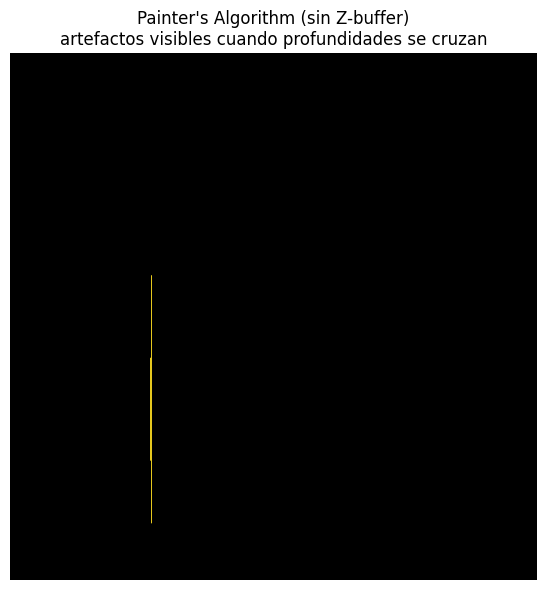

✓ Imagen guardada: media/painter_no_zbuffer.png


In [5]:
def render(tris, use_zbuffer=True):
    """Render triangles; return (color_img, depth_img) as uint8 arrays."""
    color_buf = np.zeros((H, W, 3), dtype=np.uint8)
    depth_buf = np.full((H, W), np.inf)

    draw_order = tris if use_zbuffer else painters_order(tris)

    for tri in draw_order:
        p2d = [project(v) for v in tri['verts']]
        zs  = [v[2] for v in tri['verts']]
        if any(p is None for p in p2d):
            continue
        rasterize_triangle(p2d[0], p2d[1], p2d[2],
                           zs[0], zs[1], zs[2],
                           tri['color'], color_buf, depth_buf,
                           use_zbuffer=use_zbuffer)
    return color_buf, depth_buf

# ── Painter's render ──
img_painter, depth_painter = render(triangles, use_zbuffer=False)

plt.figure(figsize=(6, 6))
plt.imshow(img_painter)
plt.title('Painter\'s Algorithm (sin Z-buffer)\nartefactos visibles cuando profundidades se cruzan')
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/painter_no_zbuffer.png', dpi=100)
plt.show()
print('✓ Imagen guardada: media/painter_no_zbuffer.png')

## 6. Renderizado CON Z-buffer

Para cada píxel guardamos la profundidad mínima vista hasta el momento.  
Solo actualizamos el color si la Z del fragmento actual **es menor** que la almacenada:

```python
if z_fragment < depth_buffer[y, x]:
    depth_buffer[y, x] = z_fragment
    color_buffer[y, x] = color
```

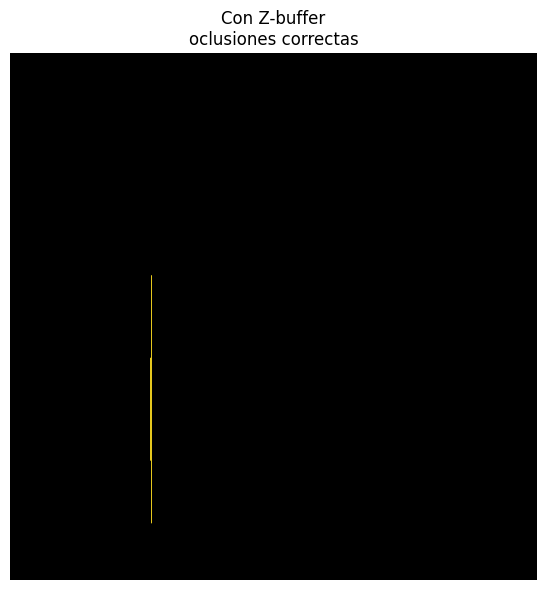

✓ Imagen guardada: media/zbuffer_correct.png


In [6]:
img_zbuf, depth_zbuf = render(triangles, use_zbuffer=True)

plt.figure(figsize=(6, 6))
plt.imshow(img_zbuf)
plt.title('Con Z-buffer\noclusiones correctas')
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/zbuffer_correct.png', dpi=100)
plt.show()
print('✓ Imagen guardada: media/zbuffer_correct.png')

## 7. Visualización del Depth Buffer

Normalizamos los valores de profundidad al rango $[0, 1]$ y los mostramos en escala de grises.  
Los píxeles más claros corresponden a objetos más cercanos a la cámara.

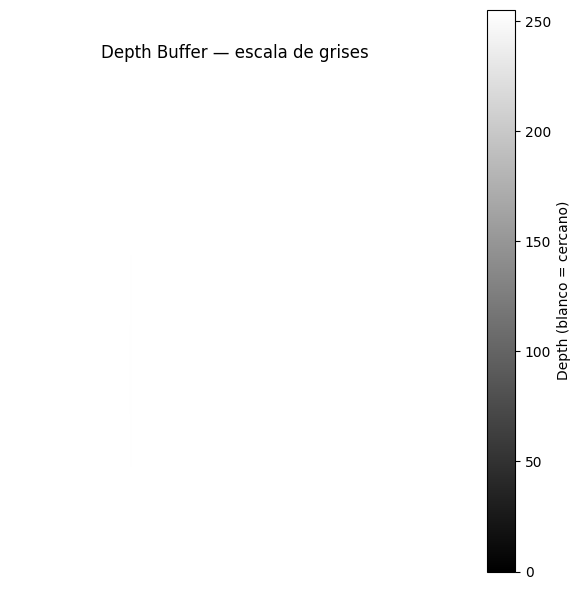

✓ Imagen guardada: media/depth_buffer_grayscale.png


In [7]:
def depth_to_image(depth_buf):
    """Normalize finite depth values to [0,1] and invert (closer = brighter)."""
    d = depth_buf.copy()
    finite_mask = np.isfinite(d)
    if finite_mask.any():
        d_min, d_max = d[finite_mask].min(), d[finite_mask].max()
        d[finite_mask] = (d[finite_mask] - d_min) / (d_max - d_min + 1e-9)
    d[~finite_mask] = 0.0   # background = black
    d = 1.0 - d             # invert: near → bright
    return (d * 255).astype(np.uint8)

depth_img = depth_to_image(depth_zbuf)

plt.figure(figsize=(6, 6))
plt.imshow(depth_img, cmap='gray', vmin=0, vmax=255)
plt.colorbar(label='Depth (blanco = cercano)')
plt.title('Depth Buffer — escala de grises')
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/depth_buffer_grayscale.png', dpi=100)
plt.show()
print('✓ Imagen guardada: media/depth_buffer_grayscale.png')

## 8. Comparación lado a lado: Painter vs. Z-buffer

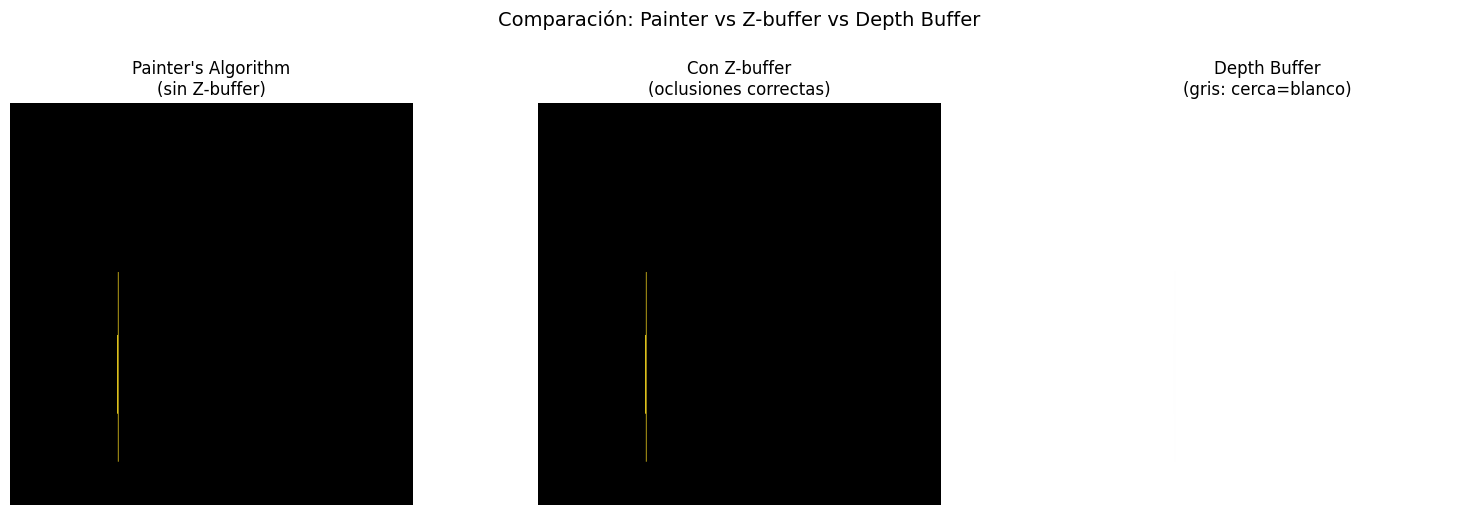

✓ Imagen guardada: media/comparacion_zbuffer.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_painter)
axes[0].set_title("Painter's Algorithm\n(sin Z-buffer)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_zbuf)
axes[1].set_title('Con Z-buffer\n(oclusiones correctas)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(depth_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Depth Buffer\n(gris: cerca=blanco)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Comparación: Painter vs Z-buffer vs Depth Buffer', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../media/comparacion_zbuffer.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Imagen guardada: media/comparacion_zbuffer.png')

## 9. Experimentación con precisión near/far

La precisión del Z-buffer no es lineal en proyección perspectiva.  
Si `near` es muy pequeño o `far` es muy grande, los valores de profundidad se agrupan hacia `far` y se pierde resolución cerca de la cámara.

Simulamos esto ajustando manualmente la profundidad relativa al rango $[0, 1]$ normalizado:

$$z_{ndc} = \frac{far + near}{far - near} + \frac{2 \cdot far \cdot near}{(far - near) \cdot Z}$$

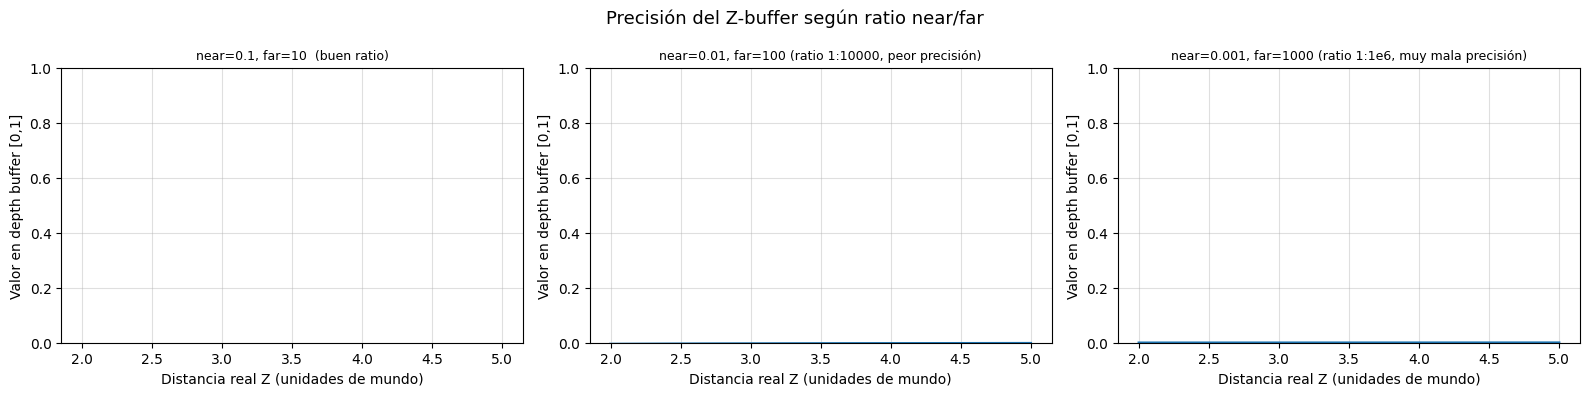

✓ Imagen guardada: media/zbuffer_precision_nearfar.png


In [9]:
def depth_precision_histogram(near, far, z_range=(2.0, 5.0), n_samples=1000):
    """Plot the NDC-z distribution for a set of Z values between z_range."""
    Z = np.linspace(z_range[0], z_range[1], n_samples)
    # OpenGL-style perspective NDC z (maps [near, far] → [-1, 1])
    A = -(far + near) / (far - near)
    B = -2 * far * near / (far - near)
    z_ndc = A + B / Z          # in [-1, 1]
    z_buf = (z_ndc + 1) / 2   # to [0, 1]
    return Z, z_buf

configs = [
    (0.1,  10,  'near=0.1, far=10  (buen ratio)'),
    (0.01, 100, 'near=0.01, far=100 (ratio 1:10000, peor precisión)'),
    (0.001, 1000, 'near=0.001, far=1000 (ratio 1:1e6, muy mala precisión)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (near, far, label) in zip(axes, configs):
    Z, z_buf = depth_precision_histogram(near, far)
    ax.plot(Z, z_buf, linewidth=2)
    ax.set_xlabel('Distancia real Z (unidades de mundo)')
    ax.set_ylabel('Valor en depth buffer [0,1]')
    ax.set_title(label, fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.set_ylim(0, 1)

plt.suptitle('Precisión del Z-buffer según ratio near/far', fontsize=13)
plt.tight_layout()
plt.savefig('../media/zbuffer_precision_nearfar.png', dpi=100)
plt.show()
print('✓ Imagen guardada: media/zbuffer_precision_nearfar.png')

## 10. Simulación de Z-fighting

El Z-fighting ocurre cuando dos superficies tienen profundidades casi iguales.  
Con precisión limitada del buffer (float32 ≈ 7 dígitos) los valores se redondean al mismo nivel y el resultado depende del orden de dibujo.

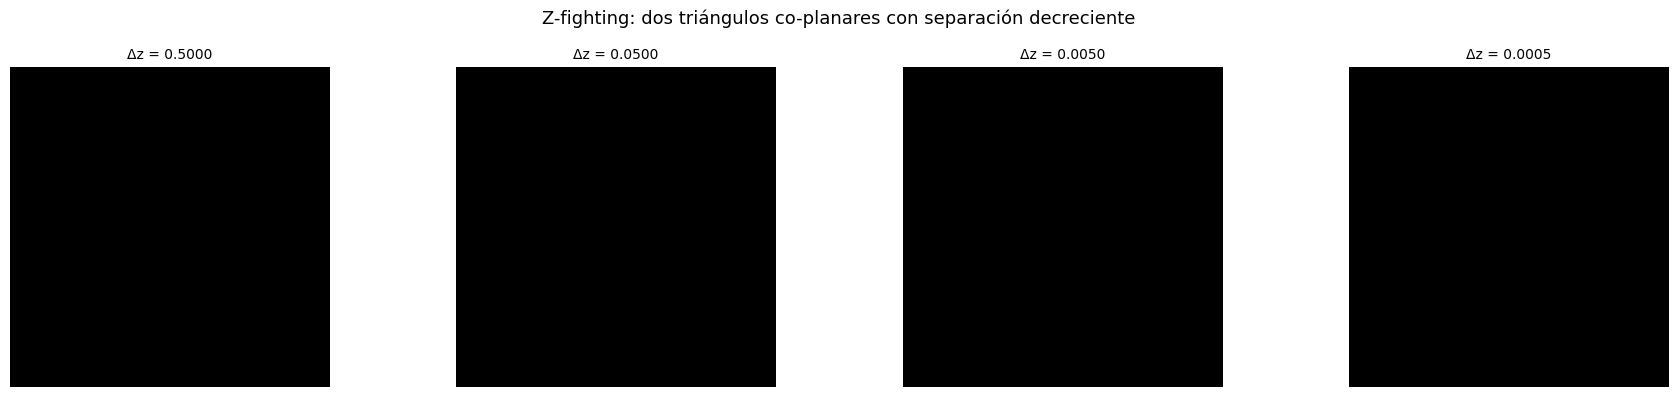

✓ Imagen guardada: media/zfighting_demo.png


In [10]:
def render_zfighting(delta_z=0.0):
    """Render two triangles at nearly the same depth."""
    z_base = 3.0
    tris_fight = [
        {
            'verts': np.array([[-1.2, -1.0, z_base],
                               [ 1.2, -1.0, z_base],
                               [ 0.0,  1.2, z_base]]),
            'color': np.array([220, 50, 50], dtype=np.uint8),
        },
        {
            'verts': np.array([[-1.2, -1.0, z_base + delta_z],
                               [ 1.2, -1.0, z_base + delta_z],
                               [ 0.0,  1.2, z_base + delta_z]]),
            'color': np.array([50, 50, 220], dtype=np.uint8),
        },
    ]
    img, _ = render(tris_fight, use_zbuffer=True)
    return img

deltas = [0.5, 0.05, 0.005, 0.0005]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, dz in zip(axes, deltas):
    img = render_zfighting(delta_z=dz)
    ax.imshow(img)
    ax.set_title(f'Δz = {dz:.4f}', fontsize=10)
    ax.axis('off')

plt.suptitle('Z-fighting: dos triángulos co-planares con separación decreciente', fontsize=13)
plt.tight_layout()
plt.savefig('../media/zfighting_demo.png', dpi=100)
plt.show()
print('✓ Imagen guardada: media/zfighting_demo.png')

## 11. GIF animado — escena con Z-buffer rotando objetos

In [11]:
os.makedirs('../media', exist_ok=True)

def rotate_y(verts, angle_deg):
    """Rotate 3-D vertices around Y axis."""
    theta = np.radians(angle_deg)
    R = np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [             0, 1,             0],
        [-np.sin(theta), 0, np.cos(theta)],
    ])
    return (R @ verts.T).T

frames = []
n_frames = 36
print('Generando GIF animado...')

for i in range(n_frames):
    angle = i * (360 / n_frames)
    rotated_tris = [
        {'verts': rotate_y(t['verts'], angle), 'color': t['color']}
        for t in triangles
    ]
    img, _ = render(rotated_tris, use_zbuffer=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    painter_img, _ = render(rotated_tris, use_zbuffer=False)
    axes[0].imshow(painter_img)
    axes[0].set_title("Painter's Algorithm")
    axes[0].axis('off')
    axes[1].imshow(img)
    axes[1].set_title('Con Z-buffer')
    axes[1].axis('off')
    plt.suptitle(f'Rotación Y = {angle:.0f}°', fontsize=13)
    plt.tight_layout()

    fig.canvas.draw()
    data = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    frame = data.reshape(fig.canvas.get_width_height()[::-1] + (4,))[:, :, :3]
    frames.append(frame)
    plt.close(fig)

gif_path = '../media/zbuffer_rotation.gif'
imageio.mimsave(gif_path, frames, duration=0.08)
print(f'✓ GIF guardado: {gif_path}')

Generando GIF animado...


✓ GIF guardado: ../media/zbuffer_rotation.gif


## 12. Resumen de aprendizajes

| Concepto | Observación |
|---|---|
| Painter's Algorithm | Falla cuando triángulos se intersecan en profundidad; orden estático incorrecto |
| Z-buffer | Resuelve el problema píxel a píxel; siempre produce oclusiones correctas |
| Depth Buffer visual | Los valores cercanos se acumulan cerca de 1.0; gradiente no lineal |
| Ratio near/far | Un ratio muy grande (1:1,000,000) comprime los valores de Z y reduce la precisión |
| Z-fighting | Con Δz < 0.001 la resolución float32 no distingue las superficies |
